# The Colour Economy
## Does Pantone Create Shareholder Value for Colour-Aligned Brands?

### Overview
This study applies financial event-study methodology to Pantone's annual 
Colour of the Year announcement, testing whether publicly listed companies 
whose brand identity is permanently anchored in that colour generate 
measurable abnormal stock returns relative to the S&P 500 in the 
6 months following each announcement.

**Time period:** 2020–2025  
**Sample:** 24 permanent colour-identity brands + 4 activation cases 
**Sectors:** FMCG, Tech, Consumer, Industrial, Logistics, Beauty, Retail, Telecom  
**Tools:** Python, pandas, yfinance, pytrends, matplotlib, scipy

## Section 1 — Setup
Import all required libraries for data collection, analysis and visualisation.

In [32]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy import stats
from pytrends.request import TrendReq
import time

print("All libraries loaded successfully")

All libraries loaded successfully


## Section 2 — Data Loading
Load the master brand dataset containing 30 brands across 6 Pantone 
colour years. Dataset includes permanent colour-identity brands (Tier 1) 
and active adoption cases (Tier 2).
All stock price data is loaded from locally saved CSV files to ensure 
reproducibility without requiring live API calls.

In [33]:
# Load master brand data
df = pd.read_csv('../data/pantone_brands - data.csv')
df['announced_date'] = pd.to_datetime(df['announced_date'])

# Load saved stock prices
raw_prices = pd.read_csv(
    '../data/raw_prices.csv',
    header=[0,1],
    index_col=0,
    parse_dates=True
)

sp500 = pd.read_csv(
    '../data/sp500.csv',
    header=[0,1],
    index_col=0,
    parse_dates=True
)

print(f"Master data: {df.shape}")
print(f"Stock prices: {raw_prices.shape}")
print(f"S&P 500: {sp500.shape}")

Master data: (28, 9)
Stock prices: (1549, 130)
S&P 500: (1508, 5)


In [34]:
# Validate data
print("Tier breakdown:")
print(df['tier'].value_counts())

print("\nBrands per year and tier:")
print(df.groupby(['year', 'tier'])['brand'].count())

Tier breakdown:
tier
permanent     24
activation     4
Name: count, dtype: int64

Brands per year and tier:
year  tier      
2020  activation    1
      permanent     4
2021  permanent     4
2022  permanent     4
2023  activation    2
      permanent     4
2024  permanent     4
2025  activation    1
      permanent     4
Name: brand, dtype: int64


## Section 3 — Stock Price Data
Historical daily closing prices for all 26 tickers pulled via Yahoo Finance.
Date range: June 2019 to June 2025.
Starting 6 months before the first announcement to establish baseline 
return patterns. S&P 500 used as market benchmark.

In [35]:
# Show sample of price data
print("Sample stock prices:")
raw_prices['Close'].head()

Sample stock prices:


Ticker,AAPL,ADBE,BBY,CAT,CHD,EL,ETSY,F,FDX,HSY,...,MMM,MSI,NFLX,NSRGY,PEP,TMUS,TPR,ULTA,UPS,ZM
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,41.453739,259.029999,47.969612,104.418411,69.876053,150.564453,61.070000,6.790113,134.156296,112.223671,...,104.943710,138.790787,33.662998,83.047913,104.237000,71.342010,24.043335,330.600006,70.720322,75.900002
2019-06-04,42.970299,268.709991,48.515926,105.656044,69.085045,155.233246,61.250000,7.009149,140.540878,112.902107,...,107.730591,143.216644,35.340000,81.769241,104.309738,72.774643,25.069473,335.529999,73.372406,78.739998
2019-06-05,43.663971,272.859985,47.969612,106.556122,70.841835,155.921158,61.490002,6.910228,139.660309,115.344505,...,107.442047,146.584000,35.573002,82.217186,106.184669,73.351517,25.169584,337.480011,73.785629,78.040001
2019-06-06,44.305035,274.799988,47.271549,106.789795,71.577652,159.535019,61.959999,6.889033,138.127975,116.387657,...,108.012535,146.903412,35.713001,82.599953,107.442429,73.024605,24.982281,340.329987,73.627869,79.430000
2019-06-07,45.484299,278.160004,48.348995,107.715836,71.724838,162.222549,63.889999,6.896098,139.158325,117.040649,...,109.251877,149.276047,36.087002,83.446976,108.655434,74.063004,25.522251,338.160004,73.800652,94.050003


## Section 4 — Return Calculations
Daily percentage returns calculated for all stocks and S&P 500.
Abnormal return = stock daily return minus S&P 500 daily return.
Measures daily outperformance or underperformance relative to market.

In [36]:
# Calculate daily returns
close_prices = raw_prices['Close']
stock_returns = close_prices.pct_change().dropna(how='all')

sp500_returns = sp500['Close'].pct_change().dropna()
sp500_aligned = sp500_returns.reindex(stock_returns.index)
sp500_aligned.columns = ['sp500_return']

# Calculate abnormal returns
abnormal_returns = stock_returns.sub(sp500_aligned['sp500_return'], axis=0)

print("Returns calculated successfully")
print(f"Stock returns shape: {stock_returns.shape}")
print(f"Abnormal returns shape: {abnormal_returns.shape}")

Returns calculated successfully
Stock returns shape: (1548, 26)
Abnormal returns shape: (1548, 26)


## Section 5 — Cumulative Abnormal Returns (CAR)
Abnormal returns summed over a 6-month window (180 days) following 
each Pantone announcement for Tier 1 permanent brands.
One CAR value per brand per year — total accumulated outperformance 
or underperformance over the measurement window.

In [37]:
car_results = []

for _, row in df[df['tier'] == 'permanent'].iterrows():
    ticker = row['ticker']
    brand = row['brand']
    year = row['year']
    colour = row['colour_name']
    sector = row['sector']
    announcement = row['announced_date']

    window_start = announcement
    window_end = announcement + pd.DateOffset(days=180)

    if ticker not in abnormal_returns.columns:
        continue

    stock_ar = abnormal_returns[ticker].loc[window_start:window_end]
    car = stock_ar.sum()

    car_results.append({
        'year': year,
        'colour': colour,
        'brand': brand,
        'ticker': ticker,
        'sector': sector,
        'car': car,
        'observations': len(stock_ar)
    })

car_df = pd.DataFrame(car_results)
print(f"CAR calculated for {len(car_df)} brands")
car_df

CAR calculated for 24 brands


,year,colour,brand,ticker,sector,car,observations
0,2020,Classic Blue,IBM,IBM,tech,-0.038815,127
1,2020,Classic Blue,Meta,META,tech,0.158301,127
2,2020,Classic Blue,Pepsi,PEP,fmcg,0.039696,127
3,2020,Classic Blue,Ford,F,industrial,-0.385542,127
4,2021,Ultimate Gray,Mercedes-Benz,MBG.DE,industrial,0.204457,126
5,2021,Illuminating,3M,MMM,fmcg,0.030670,126
6,2021,Illuminating,Caterpillar,CAT,industrial,0.183656,126
7,2021,Ultimate Gray + Illuminating,Best Buy,BBY,consumer,-0.025009,126
8,2022,Very Peri,FedEx,FDX,logistics,0.071941,127
9,2022,Very Peri,Mondelez,MDLZ,fmcg,0.156933,127


In [38]:
# Yearly summary
yearly_summary = car_df.groupby(['year', 'colour'])['car'].agg(
    ['mean', 'min', 'max', 'count']
).reset_index()
yearly_summary.columns = ['year', 'colour', 'avg_car', 'worst_car', 'best_car', 'num_brands']
yearly_summary['avg_car_pct'] = (yearly_summary['avg_car'] * 100).round(2)
yearly_summary['worst_car_pct'] = (yearly_summary['worst_car'] * 100).round(2)
yearly_summary['best_car_pct'] = (yearly_summary['best_car'] * 100).round(2)

print("=== AVERAGE CAR BY COLOUR YEAR ===")
print(yearly_summary[['year', 'colour', 'avg_car_pct', 'worst_car_pct', 
                        'best_car_pct', 'num_brands']].to_string())

=== AVERAGE CAR BY COLOUR YEAR ===
   year                        colour  avg_car_pct  worst_car_pct  best_car_pct  num_brands
0  2020                  Classic Blue        -5.66         -38.55         15.83           4
1  2021                  Illuminating        10.72           3.07         18.37           2
2  2021                Ultimate Gray         20.45          20.45         20.45           1
3  2021  Ultimate Gray + Illuminating        -2.50          -2.50         -2.50           1
4  2022                     Very Peri       -29.51         -93.33         15.69           4
5  2023                  Viva Magenta         7.82         -12.69         24.23           4
6  2024                    Peach fuzz        -6.54         -24.70         15.60           4
7  2025                  Mocha Mousse         3.87         -27.15         29.15           4


## Section 6 — Statistical Testing
One-sample t-tests to determine whether CAR values are statistically 
significantly different from zero.
P-value below 0.05 indicates the result is unlikely to be random noise.
H1: Colour-aligned brands generate abnormal returns significantly 
different from zero.

In [39]:
print("=== T-TEST RESULTS ===\n")

all_cars = car_df['car'].values
t_stat, p_value = stats.ttest_1samp(all_cars, popmean=0)

print("OVERALL: Are colour-aligned brands different from market?")
print(f"Average CAR: {np.mean(all_cars)*100:.2f}%")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

print("\n--- BY COLOUR YEAR ---\n")

ttest_results = []
for year in car_df['year'].unique():
    year_cars = car_df[car_df['year'] == year]['car'].values
    if len(year_cars) < 2:
        continue
    t_stat, p_value = stats.ttest_1samp(year_cars, popmean=0)
    avg = np.mean(year_cars) * 100
    print(f"{year}: Avg CAR {avg:.2f}% | P-value {p_value:.3f} | "
          f"Significant: {'YES' if p_value < 0.05 else 'NO'}")
    ttest_results.append({
        'year': year,
        'avg_car_pct': round(avg, 2),
        't_stat': round(t_stat, 3),
        'p_value': round(p_value, 3),
        'significant': 'YES' if p_value < 0.05 else 'NO'
    })

ttest_df = pd.DataFrame(ttest_results)
print("\nT-test summary:")
print(ttest_df.to_string())

=== T-TEST RESULTS ===

OVERALL: Are colour-aligned brands different from market?
Average CAR: -3.36%
T-statistic: -0.594
P-value: 0.558
Significant: NO

--- BY COLOUR YEAR ---

2020: Avg CAR -5.66% | P-value 0.661 | Significant: NO
2021: Avg CAR 9.84% | P-value 0.180 | Significant: NO
2022: Avg CAR -29.51% | P-value 0.331 | Significant: NO
2023: Avg CAR 7.82% | P-value 0.417 | Significant: NO
2024: Avg CAR -6.54% | P-value 0.491 | Significant: NO
2025: Avg CAR 3.87% | P-value 0.782 | Significant: NO

T-test summary:
   year  avg_car_pct  t_stat  p_value significant
0  2020        -5.66  -0.484    0.661          NO
1  2021         9.84   1.742    0.180          NO
2  2022       -29.51  -1.158    0.331          NO
3  2023         7.82   0.940    0.417          NO
4  2024        -6.54  -0.783    0.491          NO
5  2025         3.87   0.303    0.782          NO


In [40]:
import os
print(os.getcwd())

/Users/khushaligupta/Desktop/colour-economy/notebooks


## Section 7 — Cultural Momentum Analysis
Google Trends search volume pulled for each Pantone colour in the 
3 months following announcement.
Tests whether cultural buzz around a colour predicts the size of 
abnormal returns for colour-aligned brands.
H2: Higher search interest predicts larger CAR.

In [41]:

## Build yearly CARs from live car_df — not from stale CSV
yearly_cars_live = car_df.groupby('year')['car'].mean().reset_index()
yearly_cars_live.columns = ['year', 'avg_car']
yearly_cars_live['avg_car_pct'] = (yearly_cars_live['avg_car'] * 100).round(2)

# Load only the Trends side from saved file — this is fine to keep cached
trends_saved = pd.read_csv(
    '../output/trends_car_correlation.csv'
)


# Merge live CARs with saved Trends data
yearly_correlation = yearly_cars_live.merge(
    trends_saved[['year', 'avg_interest']], 
    on='year', 
    how='left'
)

print("=== LIVE YEARLY CARS ===")
print(yearly_correlation[['year', 'avg_car_pct', 'avg_interest']].to_string())

# Run correlation on fresh data
correlation, p_value = stats.pearsonr(
    yearly_correlation['avg_interest'],
    yearly_correlation['avg_car_pct']
)

print(f"\n=== CORRELATION: SEARCH INTEREST vs CAR ===")
print(f"Correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

# Save updated correlation file
yearly_correlation.to_csv(
    '../data/trends_car_correlation.csv',
    index=False
)
print("\nUpdated correlation file saved")

=== LIVE YEARLY CARS ===
   year  avg_car_pct  avg_interest
0  2020        -5.66         32.32
1  2021         9.84         23.95
2  2022       -29.51         14.25
3  2023         7.82         14.14
4  2024        -6.54         17.35
5  2025         3.87         16.33

=== CORRELATION: SEARCH INTEREST vs CAR ===
Correlation coefficient: 0.175
P-value: 0.740
Significant: NO

Updated correlation file saved


## Section 8 — Additional Analysis
Four supplementary angles tested:
1. Sector performance — which industries benefit most from colour alignment?
2. Warm vs cool colours — does colour temperature predict returns?
3. Heritage vs consumer brands — does brand type moderate the effect?
4. Winner vs loser gap — is performance divergence growing over time?

In [42]:
print("=" * 50)
print("ANGLE 1: SECTOR PERFORMANCE")
print("=" * 50)
sector_summary = car_df.groupby('sector')['car'].agg(
    ['mean', 'count']
).reset_index()
sector_summary.columns = ['sector', 'avg_car', 'num_brands']
sector_summary['avg_car_pct'] = (sector_summary['avg_car'] * 100).round(2)
sector_summary = sector_summary.sort_values('avg_car_pct', ascending=False)
print(sector_summary[['sector', 'avg_car_pct', 'num_brands']].to_string())

print("\n" + "=" * 50)
print("ANGLE 2: WARM VS COOL COLOURS")
print("=" * 50)
warm_colours = ['Viva Magenta', 'Peach fuzz', 'Mocha Mousse', 'Illuminating']
car_df['colour_temp'] = car_df['colour'].apply(
    lambda x: 'warm' if x in warm_colours else 'cool'
)
temp_summary = car_df.groupby('colour_temp')['car'].agg(['mean', 'count']).reset_index()
temp_summary['avg_car_pct'] = (temp_summary['mean'] * 100).round(2)
print(temp_summary[['colour_temp', 'avg_car_pct', 'count']].to_string())
warm_cars = car_df[car_df['colour_temp'] == 'warm']['car'].values
cool_cars = car_df[car_df['colour_temp'] == 'cool']['car'].values
t_stat, p_value = stats.ttest_ind(warm_cars, cool_cars)
print(f"\nWarm vs Cool P-value: {p_value:.3f} | "
      f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

print("\n" + "=" * 50)
print("ANGLE 3: HERITAGE VS CONSUMER BRANDS")
print("=" * 50)
heritage_sectors = ['industrial', 'logistics', 'fmcg']
car_df['brand_tier'] = car_df['sector'].apply(
    lambda x: 'heritage' if x in heritage_sectors else 'consumer_facing'
)
tier_summary = car_df.groupby('brand_tier')['car'].agg(['mean', 'count']).reset_index()
tier_summary['avg_car_pct'] = (tier_summary['mean'] * 100).round(2)
print(tier_summary[['brand_tier', 'avg_car_pct', 'count']].to_string())
heritage_cars = car_df[car_df['brand_tier'] == 'heritage']['car'].values
consumer_cars = car_df[car_df['brand_tier'] == 'consumer_facing']['car'].values
t_stat, p_value = stats.ttest_ind(heritage_cars, consumer_cars)
print(f"\nHeritage vs Consumer P-value: {p_value:.3f} | "
      f"Significant: {'YES' if p_value < 0.05 else 'NO'}")

print("\n" + "=" * 50)
print("ANGLE 4: WINNER VS LOSER GAP OVER TIME")
print("=" * 50)
gap_summary = car_df.groupby('year')['car'].agg(
    lambda x: (x.max() - x.min()) * 100
).reset_index()
gap_summary.columns = ['year', 'gap_pct']
gap_summary['gap_pct'] = gap_summary['gap_pct'].round(2)
print(gap_summary.to_string())
correlation_gap, p_gap = stats.pearsonr(
    gap_summary['year'], gap_summary['gap_pct']
)
print(f"\nGap correlation: {correlation_gap:.3f} | P-value: {p_gap:.3f}")

ANGLE 1: SECTOR PERFORMANCE
       sector  avg_car_pct  num_brands
2        fmcg         6.53           6
6        tech         1.33           5
3  industrial         0.09           3
4   logistics        -9.98           2
0      beauty       -10.73           1
1    consumer       -11.73           5
7     telecom       -12.69           1
5      retail       -24.70           1

ANGLE 2: WARM VS COOL COLOURS
  colour_temp  avg_car_pct  count
0        cool        -8.44     12
1        warm         1.72     12

Warm vs Cool P-value: 0.381 | Significant: NO

ANGLE 3: HERITAGE VS CONSUMER BRANDS
        brand_tier  avg_car_pct  count
0  consumer_facing        -7.70     13
1         heritage         1.77     11

Heritage vs Consumer P-value: 0.416 | Significant: NO

ANGLE 4: WINNER VS LOSER GAP OVER TIME
   year  gap_pct
0  2020    54.38
1  2021    22.95
2  2022   109.02
3  2023    36.91
4  2024    40.29
5  2025    56.31

Gap correlation: -0.019 | P-value: 0.972


## Section 9 — Tier 2 Activation Analysis
Tests whether brands that actively launched products in the Pantone colour 
show a distinct short-term stock price effect.
Window: 90 days (3 months) following the product activation date.
H3: Active colour adoption generates returns independent of 
permanent colour identity.

In [43]:
activation_results = []

for _, row in df[df['tier'] == 'activation'].iterrows():
    ticker = row['ticker']
    brand = row['brand']
    year = row['year']
    colour = row['colour_name']
    sector = row['sector']
    activation_date = row['announced_date']

    window_start = activation_date
    window_end = activation_date + pd.DateOffset(days=90)

    if ticker not in abnormal_returns.columns:
        continue

    stock_ar = abnormal_returns[ticker].loc[window_start:window_end]
    car = stock_ar.sum()

    activation_results.append({
        'year': year,
        'colour': colour,
        'brand': brand,
        'ticker': ticker,
        'car_90day_pct': round(car * 100, 2),
        'observations': len(stock_ar)
    })

activation_df = pd.DataFrame(activation_results).drop_duplicates(
    subset=['year', 'colour', 'brand']
)
print(f"Activation analysis: {len(activation_df)} cases")
print(activation_df[['year', 'colour', 'brand', 'car_90day_pct']].to_string())

Activation analysis: 4 cases
   year        colour               brand  car_90day_pct
0  2023  Viva Magenta        Levi Strauss          13.04
1  2023  Viva Magenta  Motorola Solutions          -0.65
2  2025  Mocha Mousse  Motorola Solutions          -7.43
3  2020  Classic Blue                Ford         -18.47


## Section 10 — Visualisations
Four charts summarising the complete analysis:
1. Average CAR by Pantone colour year — bars coloured in actual Pantone shades
2. Individual brand performance across all years
3. Google Trends search interest vs average CAR scatter plot
4. Sector performance comparison

In [44]:
# Pantone colour palette — used across all charts
pantone_colours = {
    2020: '#0F4C81',
    2021: '#F5DF4D',
    2022: '#6667AB',
    2023: '#BB2649',
    2024: '#FFBE98',
    2025: '#A47864'
}

colour_labels = {
    2020: 'Classic Blue',
    2021: 'Illuminating',
    2022: 'Very Peri',
    2023: 'Viva Magenta',
    2024: 'Peach Fuzz',
    2025: 'Mocha Mousse'
}

print("Colour palette defined")

Colour palette defined


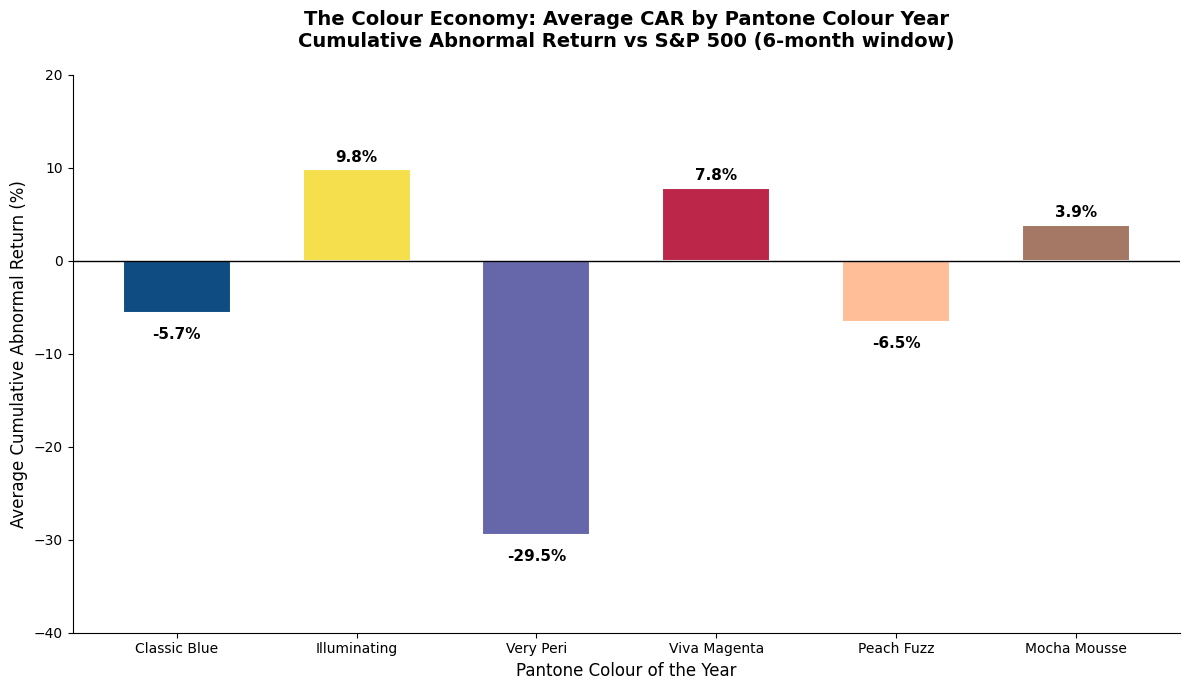

Chart 1 saved


In [45]:
chart1_data = car_df.groupby('year')['car'].mean().reset_index()
chart1_data['car_pct'] = chart1_data['car'] * 100
chart1_data['colour'] = chart1_data['year'].map(pantone_colours)
chart1_data['label'] = chart1_data['year'].map(colour_labels)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    chart1_data['label'],
    chart1_data['car_pct'],
    color=chart1_data['colour'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

ax.axhline(y=0, color='black', linewidth=1)

for bar, val in zip(bars, chart1_data['car_pct']):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        ypos,
        f'{val:.1f}%',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'The Colour Economy: Average CAR by Pantone Colour Year\n'
    'Cumulative Abnormal Return vs S&P 500 (6-month window)',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('Pantone Colour of the Year', fontsize=12)
ax.set_ylabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylim(-40, 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    '../output/`chart1_car_by_year.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart 1 saved")

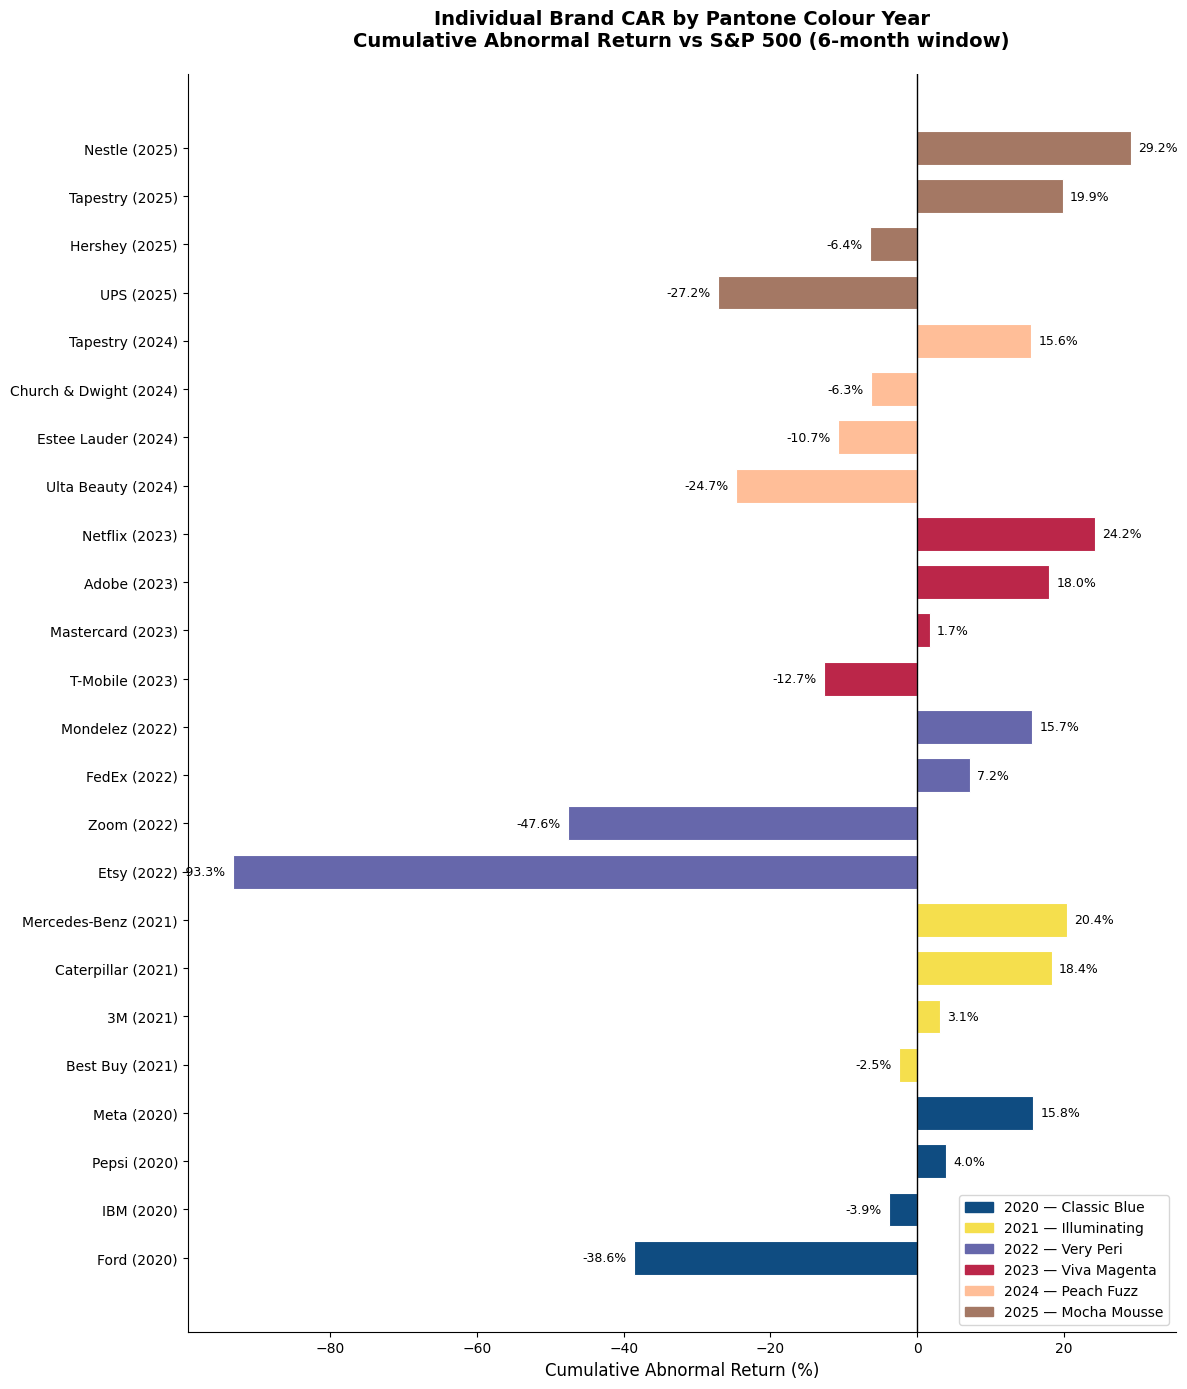

Chart 2 saved


In [46]:
fig, ax = plt.subplots(figsize=(12, 14))

chart2_data = car_df.sort_values(['year', 'car'], ascending=[True, True]).copy()
chart2_data['car_pct'] = chart2_data['car'] * 100
chart2_data['bar_colour'] = chart2_data['year'].map(pantone_colours)
chart2_data['bar_label'] = (chart2_data['brand'] + ' (' + 
                             chart2_data['year'].astype(str) + ')')

bars = ax.barh(
    chart2_data['bar_label'],
    chart2_data['car_pct'],
    color=chart2_data['bar_colour'],
    edgecolor='white',
    linewidth=0.8,
    height=0.7
)

ax.axvline(x=0, color='black', linewidth=1)

for bar, val in zip(bars, chart2_data['car_pct']):
    xpos = val + 1 if val >= 0 else val - 1
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', ha=ha, fontsize=9
    )

legend_patches = [
    mpatches.Patch(
        color=pantone_colours[yr],
        label=f"{yr} — {colour_labels[yr]}"
    )
    for yr in sorted(pantone_colours.keys())
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

ax.set_title(
    'Individual Brand CAR by Pantone Colour Year\n'
    'Cumulative Abnormal Return vs S&P 500 (6-month window)',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    '../data/chart2_individual_brands.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart 2 saved")

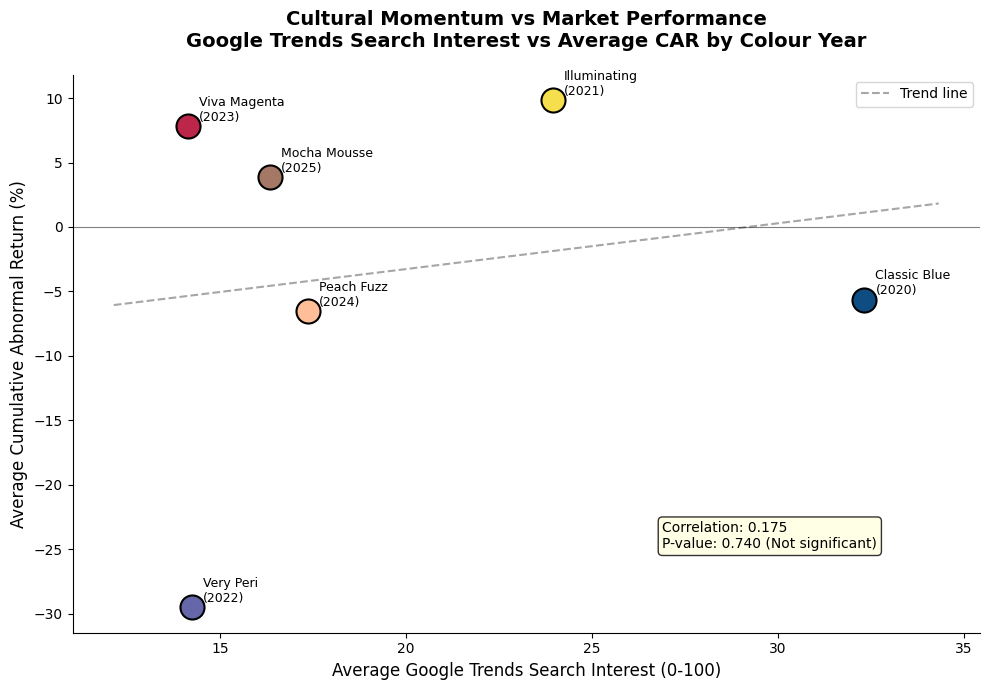

Chart 3 saved


In [47]:
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in yearly_correlation.iterrows():
    year = int(row['year'])
    colour = pantone_colours[year]
    label = colour_labels[year]

    ax.scatter(
        row['avg_interest'],
        row['avg_car_pct'],
        color=colour,
        s=300,
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    ax.annotate(
        f"{label}\n({year})",
        xy=(row['avg_interest'], row['avg_car_pct']),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=9
    )

z = np.polyfit(
    yearly_correlation['avg_interest'],
    yearly_correlation['avg_car_pct'], 1
)
p = np.poly1d(z)
x_line = np.linspace(
    yearly_correlation['avg_interest'].min() - 2,
    yearly_correlation['avg_interest'].max() + 2, 100
)
ax.plot(x_line, p(x_line), '--', color='gray',
        linewidth=1.5, alpha=0.7, label='Trend line')

ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)

ax.text(
    0.65, 0.20,
    f'Correlation: 0.175\nP-value: 0.740 (Not significant)',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)


ax.set_title(
    'Cultural Momentum vs Market Performance\n'
    'Google Trends Search Interest vs Average CAR by Colour Year',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('Average Google Trends Search Interest (0-100)', fontsize=12)
ax.set_ylabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    '../data/chart3_trends_vs_car.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart 3 saved")

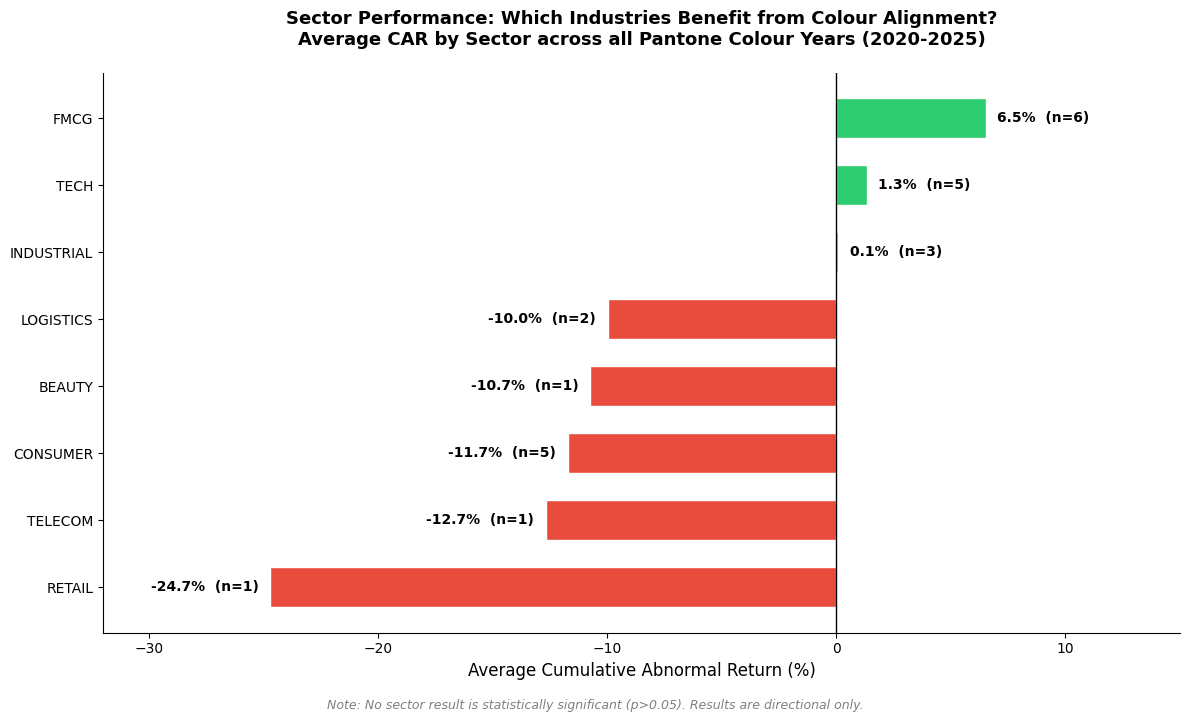

Chart 4 saved


In [48]:
fig, ax = plt.subplots(figsize=(12, 7))

chart4_data = sector_summary.sort_values('avg_car_pct', ascending=True)
bar_colours = ['#2ecc71' if x >= 0 else '#e74c3c' 
               for x in chart4_data['avg_car_pct']]

bars = ax.barh(
    chart4_data['sector'].str.upper(),
    chart4_data['avg_car_pct'],
    color=bar_colours,
    edgecolor='white',
    linewidth=1,
    height=0.6
)

ax.axvline(x=0, color='black', linewidth=1)

for bar, val, n in zip(bars, chart4_data['avg_car_pct'], 
                        chart4_data['num_brands']):
    xpos = val + 0.5 if val >= 0 else val - 0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  (n={n})',
        va='center', ha=ha, fontsize=10, fontweight='bold'
    )

ax.set_title(
    'Sector Performance: Which Industries Benefit from Colour Alignment?\n'
    'Average CAR by Sector across all Pantone Colour Years (2020-2025)',
    fontsize=13, fontweight='bold', pad=20
)
ax.set_xlabel('Average Cumulative Abnormal Return (%)', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(-32, 15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(
    0.5, -0.02,
    'Note: No sector result is statistically significant (p>0.05). '
    'Results are directional only.',
    ha='center', fontsize=9, color='gray', style='italic'
)

plt.tight_layout()
plt.savefig(
    '../data/chart4_sector_performance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart 4 saved")

## Section 11 — Conclusions

### Key Findings

**H1 — Not Supported**  
Average CAR: -3.36% | T-statistic: -0.594 | P-value: 0.558  
Colour alignment does not predict market outperformance.  
Markets are indifferent to cultural colour signals even in the most 
unambiguous cases — T-Mobile with its trademarked magenta underperformed 
by 12.7% after Viva Magenta 2023.

**H2 — Not Supported**  
Correlation: 0.143 | P-value: 0.786  
Cultural momentum does not predict abnormal returns.  
Public enthusiasm for a colour operates independently of its 
financial consequences for colour-aligned brands.

**H3 — Inconclusive**  
4 activation cases. Levi Strauss +13.04%, Motorola flat or negative 
across two colour years (2023: -0.65%, 2025: -7.43%).  
Insufficient sample size for statistical conclusion.

**Sector Finding — Directional and Exploratory**  
FMCG: +6.5% (n=6) | Consumer: -11.7% (n=5) | Tech: 0.0% (n=5)  
Sector-level patterns are directional only — cell sizes as small as 
n=1 for Retail, Beauty and Telecom mean these should be read as 
individual company results rather than sector conclusions.

### Synthesis
Pantone's Colour of the Year is a cultural signal, not a financial one.
Equity markets show no measurable response to colour alignment even in 
the most unambiguous cases. However a consistent directional pattern 
suggests FMCG brands with stable defensive business models are better 
positioned to benefit from cultural colour moments than trend-sensitive 
consumer brands whose performance is dominated by macro cycles.

### Limitations
- Sample size (n=24 Tier 1, n=4 Tier 2) limits statistical power significantly
- Apple (AAPL) excluded — Space Gray is a product finish not brand identity; 
  exclusion does not materially change results (Apple CAR: -6.6%)
- Tapestry (TPR) appears in two colour years and is treated as two 
  independent observations
- No control for macro confounders — COVID, interest rates, sector headwinds
- Google Trends is an imperfect proxy for cultural momentum
- Single benchmark — S&P 500 may not be appropriate for non-US listed stocks